In [100]:
!pip install pandas matplotlib seaborn

import pandas as pd
import numpy as np
import sqlite3
import os
import seaborn  as sns
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, text
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.cluster import MiniBatchKMeans
from IPython.display import display
from sklearn.preprocessing import StandardScaler
from matplotlib.ticker import FuncFormatter

In [101]:
QVI_txn_raw = pd.read_excel(r'/Users/ying/Downloads/QVI_transaction_data(1).xlsx')

QVI_pb_raw = pd.read_csv(r'/Users/ying/Downloads/QVI_purchase_behaviour(1).csv')

print('Data is set done')

Data is set done


In [119]:
QVI_txn = QVI_txn_raw.copy()

QVI_pb = QVI_pb_raw.copy()

In [120]:
display(QVI_txn.info())
display(QVI_txn.describe())
display(QVI_txn.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            264836 non-null  int64  
 1   STORE_NBR       264836 non-null  int64  
 2   LYLTY_CARD_NBR  264836 non-null  int64  
 3   TXN_ID          264836 non-null  int64  
 4   PROD_NBR        264836 non-null  int64  
 5   PROD_NAME       264836 non-null  object 
 6   PROD_QTY        264836 non-null  int64  
 7   TOT_SALES       264836 non-null  float64
dtypes: float64(1), int64(6), object(1)
memory usage: 16.2+ MB


None

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,264836.000000,264836.00000,2.648360e+05,2.648360e+05,264836.000000,264836.000000,264836.000000
mean,43464.036260,135.08011,1.355495e+05,1.351583e+05,56.583157,1.907309,7.304200
std,105.389282,76.78418,8.057998e+04,7.813303e+04,32.826638,0.643654,3.083226
min,43282.000000,1.00000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.500000
25%,43373.000000,70.00000,7.002100e+04,6.760150e+04,28.000000,2.000000,5.400000
50%,43464.000000,130.00000,1.303575e+05,1.351375e+05,56.000000,2.000000,7.400000
75%,43555.000000,203.00000,2.030942e+05,2.027012e+05,85.000000,2.000000,9.200000
max,43646.000000,272.00000,2.373711e+06,2.415841e+06,114.000000,200.000000,650.000000


DATE              0
STORE_NBR         0
LYLTY_CARD_NBR    0
TXN_ID            0
PROD_NBR          0
PROD_NAME         0
PROD_QTY          0
TOT_SALES         0
dtype: int64

In [121]:
## change data type, like 'DATE'
# Convert the 'DATE' column in QVI_txn from serial number to a pandas datetime type
QVI_txn['DATE'] = pd.to_datetime(QVI_txn['DATE'], unit='D', origin='1899-12-30')
QVI_txn['DATE'].head()

0   2018-10-17
1   2019-05-14
2   2019-05-20
3   2018-08-17
4   2018-08-18
Name: DATE, dtype: datetime64[ns]

In [122]:
# 1. Get ONLY the unique product names
distinct_products = QVI_txn['PROD_NAME'].unique()

all_words = []

# 2. Loop through the unique names, not the whole dataframe
for name in distinct_products:
    # Split the name into words
    words = name.split()
    all_words.extend(words)

# 3. Clean the words (remove numbers and ensure they contain letters)
all_words = [w for w in all_words if not re.search(r'\d', w)]
all_words = [w for w in all_words if re.search(r'[A-Za-z]', w)]

# 4. Count the frequency
word_counts = Counter(all_words)

# 5. Show the top 20
most_common_words = word_counts.most_common(20)
print("Unique Product Word Frequency (Top 20):")
for word, count in most_common_words:
    print(f"{word}: {count}")

Unique Product Word Frequency (Top 20):
Chips: 21
Smiths: 16
Crinkle: 14
Cut: 14
Kettle: 13
Cheese: 12
Salt: 12
Original: 10
Chip: 9
Salsa: 9
Doritos: 9
Corn: 8
Pringles: 8
RRD: 8
Chicken: 7
WW: 7
Sour: 6
Sea: 6
Thinly: 5
Vinegar: 5


In [123]:
# lower the prod_name
QVI_txn['PROD_NAME'] = QVI_txn['PROD_NAME'].str.lower()

# filter out and delete the rows containing 'salsa' in prod_name, only keep the rows that do NOT contain 'salsa'
QVI_txn_chip = QVI_txn[~QVI_txn['PROD_NAME'].str.contains('salsa')]


In [125]:
display(QVI_txn_chip.info())
display(QVI_txn_chip.describe())
display(QVI_txn_chip.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 246742 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   DATE            246742 non-null  datetime64[ns]
 1   STORE_NBR       246742 non-null  int64         
 2   LYLTY_CARD_NBR  246742 non-null  int64         
 3   TXN_ID          246742 non-null  int64         
 4   PROD_NBR        246742 non-null  int64         
 5   PROD_NAME       246742 non-null  object        
 6   PROD_QTY        246742 non-null  int64         
 7   TOT_SALES       246742 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(5), object(1)
memory usage: 16.9+ MB


None

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,246742,246742.000000,2.467420e+05,2.467420e+05,246742.000000,246742.000000,246742.000000
mean,2018-12-30 01:19:01.211467520,135.051098,1.355310e+05,1.351311e+05,56.351789,1.908062,7.321322
min,2018-07-01 00:00:00,1.000000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.700000
25%,2018-09-30 00:00:00,70.000000,7.001500e+04,6.756925e+04,26.000000,2.000000,5.800000
50%,2018-12-30 00:00:00,130.000000,1.303670e+05,1.351830e+05,53.000000,2.000000,7.400000
75%,2019-03-31 00:00:00,203.000000,2.030840e+05,2.026538e+05,87.000000,2.000000,8.800000
max,2019-06-30 00:00:00,272.000000,2.373711e+06,2.415841e+06,114.000000,200.000000,650.000000
std,NaN,76.787096,8.071528e+04,7.814772e+04,33.695428,0.659831,3.077828


DATE              0
STORE_NBR         0
LYLTY_CARD_NBR    0
TXN_ID            0
PROD_NBR          0
PROD_NAME         0
PROD_QTY          0
TOT_SALES         0
dtype: int64

In [131]:
# find out the outilers where PROD_QTY is 200
outliers = QVI_txn_chip[QVI_txn_chip['PROD_QTY'] == 200]
display("Outliers with PROD_QTY = 200:")
display(outliers)

# find out the outilers where TOT_SALES is 650
outliers_sales = QVI_txn_chip[QVI_txn_chip['TOT_SALES'] == 650]
display("Outliers with TOT_SALES = 650:")
display(outliers_sales)

# see how many orders the customer with outliers has
customer_outliers = QVI_txn_chip[QVI_txn_chip['LYLTY_CARD_NBR'] == 226000]
display("Transactions for customer with outliers:")
display(customer_outliers)

## so we can see that the customer with outliers has 2 transactions, and both of them have PROD_QTY of 200 and TOT_SALES of 650, which are the outliers we found. Therefore, we can conclude that these outliers are likely due to data entry errors or some other issues, and we should consider removing them from our analysis to avoid skewing our results.
# remove the outliers from the dataset
QVI_txn_chip_cleaned = QVI_txn_chip[~((QVI_txn_chip['LYLTY_CARD_NBR'] == 226000) & (QVI_txn_chip['PROD_QTY'] == 200) & (QVI_txn_chip['TOT_SALES'] == 650))]
display(QVI_txn_chip_cleaned.info())
display(QVI_txn_chip_cleaned.describe())

'Outliers with PROD_QTY = 200:'

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
69762,2018-08-19,226,226000,226201,4,dorito corn chp supreme 380g,200,650.0
69763,2019-05-20,226,226000,226210,4,dorito corn chp supreme 380g,200,650.0


'Outliers with TOT_SALES = 650:'

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
69762,2018-08-19,226,226000,226201,4,dorito corn chp supreme 380g,200,650.0
69763,2019-05-20,226,226000,226210,4,dorito corn chp supreme 380g,200,650.0


'Transactions for customer with outliers:'

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
69762,2018-08-19,226,226000,226201,4,dorito corn chp supreme 380g,200,650.0
69763,2019-05-20,226,226000,226210,4,dorito corn chp supreme 380g,200,650.0


<class 'pandas.core.frame.DataFrame'>
Index: 246740 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   DATE            246740 non-null  datetime64[ns]
 1   STORE_NBR       246740 non-null  int64         
 2   LYLTY_CARD_NBR  246740 non-null  int64         
 3   TXN_ID          246740 non-null  int64         
 4   PROD_NBR        246740 non-null  int64         
 5   PROD_NAME       246740 non-null  object        
 6   PROD_QTY        246740 non-null  int64         
 7   TOT_SALES       246740 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(5), object(1)
memory usage: 16.9+ MB


None

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,246740,246740.000000,2.467400e+05,2.467400e+05,246740.000000,246740.000000,246740.000000
mean,2018-12-30 01:18:58.448569344,135.050361,1.355303e+05,1.351304e+05,56.352213,1.906456,7.316113
min,2018-07-01 00:00:00,1.000000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.700000
25%,2018-09-30 00:00:00,70.000000,7.001500e+04,6.756875e+04,26.000000,2.000000,5.800000
50%,2018-12-30 00:00:00,130.000000,1.303670e+05,1.351815e+05,53.000000,2.000000,7.400000
75%,2019-03-31 00:00:00,203.000000,2.030832e+05,2.026522e+05,87.000000,2.000000,8.800000
max,2019-06-30 00:00:00,272.000000,2.373711e+06,2.415841e+06,114.000000,5.000000,29.500000
std,NaN,76.786971,8.071520e+04,7.814760e+04,33.695235,0.342499,2.474897


In [133]:
# check the date range of the transactions and calculate how many days of transactions we have in the dataset
min_date = QVI_txn_chip_cleaned['DATE'].min()
max_date = QVI_txn_chip_cleaned['DATE'].max()
date_range = max_date - min_date
num_days = date_range.days
print(f"Date range: {min_date} to {max_date}")
print(f"Number of days of transactions: {num_days} days")

# find out which date is missing in the dataset
all_dates = pd.date_range(start=min_date, end=max_date)
missing_dates = all_dates[~all_dates.isin(QVI_txn_chip_cleaned['DATE'])]
print("Missing dates in the dataset:")
print(missing_dates)

Date range: 2018-07-01 00:00:00 to 2019-06-30 00:00:00
Number of days of transactions: 364 days
Missing dates in the dataset:
DatetimeIndex(['2018-12-25'], dtype='datetime64[ns]', freq='D')


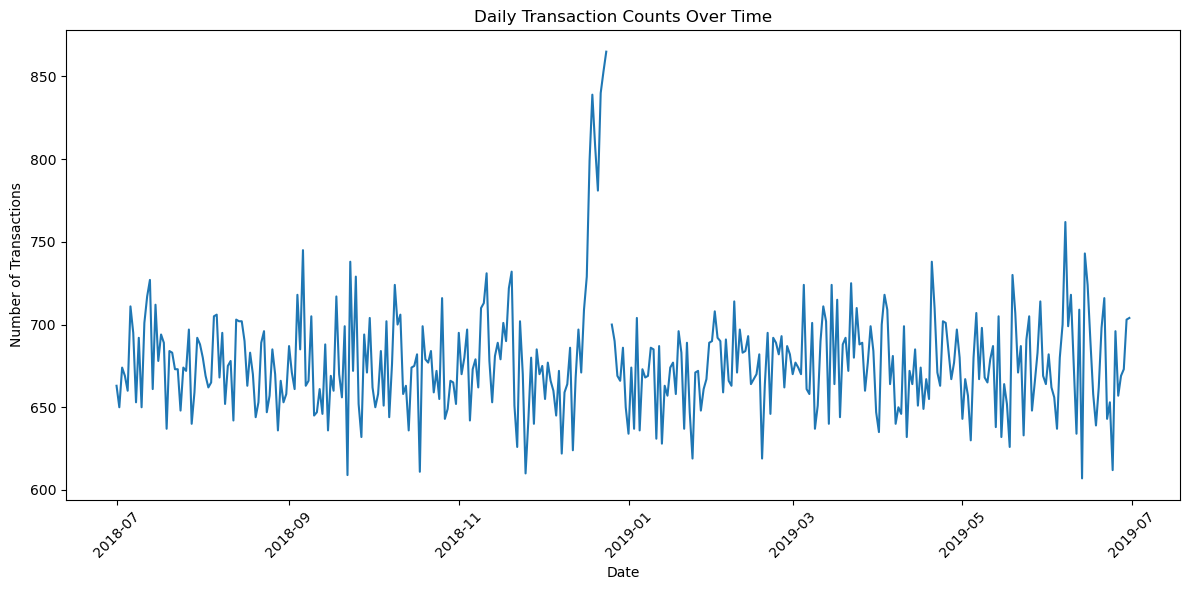

In [ ]:
# calculate the transaction count per day and plot the trend of transactions over DATE, if there are missing dates, keep the value null or blank in the plot and do not fill it with 0, because we want to see the trend of transactions over time and filling missing dates with 0 would distort the trend and make it look like there were no transactions on those days, which may not be accurate.
transaction_counts = QVI_txn_chip_cleaned.groupby('DATE').size().reindex(all_dates, fill_value=np.nan)
plt.figure(figsize=(12, 6))
plt.plot(transaction_counts.index, transaction_counts.values, linestyle='-')
plt.title('Daily Transaction Counts Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

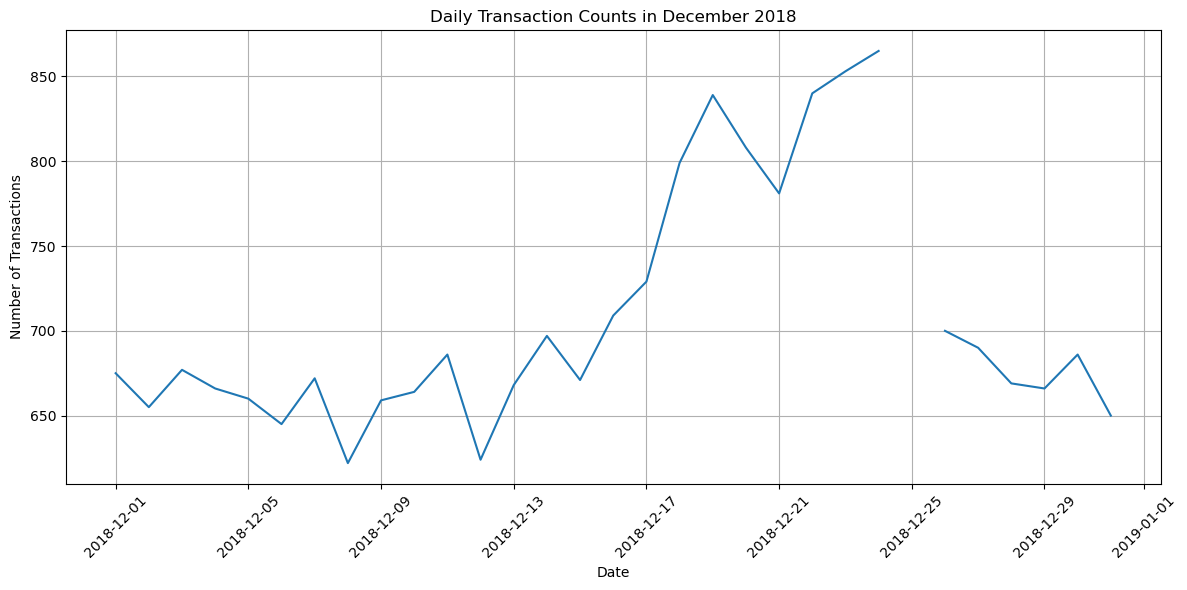

In [148]:
# dive into the daily trend of December 2018, see if there is any pattern or anomaly in that month, if there are missing dates, keep the value null or blank in the plot and do not fill it with 0, and show every single date in the x-axis, because we want to see the trend of transactions over time and filling missing dates with 0 would distort the trend and make it look like there were no transactions on those days, which may not be accurate, and showing every single date in the x-axis would help us to identify any pattern or anomaly in that month more clearly.
# Filter the data for December 2018
december_data = QVI_txn_chip_cleaned[(QVI_txn_chip_cleaned['DATE'] >= '2018-12-01') & (QVI_txn_chip_cleaned['DATE'] <= '2018-12-31')]
# Create a date range for December 2018
december_dates = pd.date_range(start='2018-12-01', end='2018-12-31')
# Calculate daily transaction counts for December 2018, keeping missing dates as NaN
december_transaction_counts = december_data.groupby('DATE').size().reindex(december_dates, fill_value=np.nan)
# Plot the daily transaction counts for December 2018
plt.figure(figsize=(12, 6))
plt.plot(december_transaction_counts.index, december_transaction_counts.values, linestyle='-')
plt.title('Daily Transaction Counts in December 2018')
plt.xlabel('Date')
plt.ylabel('Number of Transactions')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [150]:
QVI_txn_chip_cleaned

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,2018-10-17,1,1000,1,5,natural chip compny seasalt175g,2,6.0
1,2019-05-14,1,1307,348,66,ccs nacho cheese 175g,3,6.3
2,2019-05-20,1,1343,383,61,smiths crinkle cut chips chicken 170g,2,2.9
3,2018-08-17,2,2373,974,69,smiths chip thinly s/cream&onion 175g,5,15.0
4,2018-08-18,2,2426,1038,108,kettle tortilla chpshny&jlpno chili 150g,3,13.8
...,...,...,...,...,...,...,...,...
264831,2019-03-09,272,272319,270088,89,kettle sweet chilli and sour cream 175g,2,10.8
264832,2018-08-13,272,272358,270154,74,tostitos splash of lime 175g,1,4.4
264833,2018-11-06,272,272379,270187,51,doritos mexicana 170g,2,8.8
264834,2018-12-27,272,272379,270188,42,doritos corn chip mexican jalapeno 150g,2,7.8


In [152]:
# extract the brand name from the product name, we can assume that the brand name is the first word in the product name, so we can use the split function to extract the first word as the brand name and create a new column called 'BRAND' to store the extracted brand names.
QVI_txn_chip_cleaned['BRAND'] = QVI_txn_chip_cleaned['PROD_NAME'].str.split().str[0]
QVI_txn_chip_cleaned.head()

# see the brand list and the count of each brand
brand_counts = QVI_txn_chip_cleaned['BRAND'].value_counts()
print("Brand Counts:")
print(brand_counts)

Brand Counts:
BRAND
kettle        41288
smiths        27390
pringles      25102
doritos       22041
thins         14075
rrd           11894
infuzions     11057
ww            10320
cobs           9693
tostitos       9471
twisties       9454
tyrrells       6442
grain          6272
natural        6050
cheezels       4603
ccs            4551
red            4427
dorito         3183
infzns         3144
smith          2963
cheetos        2927
snbts          1576
burger         1564
woolworths     1516
grnwves        1468
sunbites       1432
ncc            1419
french         1418
Name: count, dtype: int64


/var/folders/_d/xcgr17q96l95x2dcnvhdt6sw0000gn/T/ipykernel_61194/1724784016.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  QVI_txn_chip_cleaned['BRAND'] = QVI_txn_chip_cleaned['PROD_NAME'].str.split().str[0]


In [154]:
# brand 'rrd' and 'red' are likely the same brand, unify them by using 'rrd',
# brand 'doritos' and 'dorito' are likely the same brand, unify them by using 'doritos',
# 'smiths' and 'smith' are likely the same brand, unify them by using 'smiths'
# 'ncc' and 'natural' are likely the same brand, unify them by using 'natural'
# 'infzns' and 'infuzions' are likely the same brand, unify them by using 'infuzions'
# 'ww' and 'woolworths' are likely the same brand, unify them by using 'woolworths'
# 'snbts' and 'sunbites' are likely the same brand, unify them by using 'sunbites'
# 'grain' and 'grnwves' are likely the same brand, unify them by using 'grnwves'
QVI_txn_chip_cleaned['BRAND'] = QVI_txn_chip_cleaned['BRAND'].replace({
    'red': 'rrd',
    'dorito': 'doritos',
    'smith': 'smiths',
    'ncc': 'natural',
    'infzns': 'infuzions',
    'ww': 'woolworths',
    'snbts': 'sunbites',
    'grain': 'grnwves'
})


/var/folders/_d/xcgr17q96l95x2dcnvhdt6sw0000gn/T/ipykernel_61194/3932999967.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  QVI_txn_chip_cleaned['BRAND'] = QVI_txn_chip_cleaned['BRAND'].replace({


In [ ]:
# see the updated brand list and the count of each brand after unifying the similar brands
updated_brand_counts = QVI_txn_chip_cleaned['BRAND'].value_counts()
print("Updated Brand Counts:")
print(updated_brand_counts)

Updated Brand Counts:
BRAND
kettle        41288
smiths        30353
doritos       25224
pringles      25102
rrd           16321
infuzions     14201
thins         14075
woolworths    11836
cobs           9693
tostitos       9471
twisties       9454
grnwves        7740
natural        7469
tyrrells       6442
cheezels       4603
ccs            4551
sunbites       3008
cheetos        2927
burger         1564
french         1418
Name: count, dtype: int64


In [157]:
# The Second Dataset
QVI_pb.head()

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


In [158]:
display(QVI_pb.info())
display(QVI_pb.describe())
display(QVI_pb.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   LYLTY_CARD_NBR    72637 non-null  int64 
 1   LIFESTAGE         72637 non-null  object
 2   PREMIUM_CUSTOMER  72637 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


None

,LYLTY_CARD_NBR
count,7.263700e+04
mean,1.361859e+05
std,8.989293e+04
min,1.000000e+03
25%,6.620200e+04
50%,1.340400e+05
75%,2.033750e+05
max,2.373711e+06


LYLTY_CARD_NBR      0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

In [159]:
QVI_complete_raw = pd.merge(QVI_txn_chip_cleaned,QVI_pb,on='LYLTY_CARD_NBR',how='inner')
QVI_complete = QVI_complete_raw.copy()
QVI_complete.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1,1000,1,5,natural chip compny seasalt175g,2,6.0,natural,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,ccs nacho cheese 175g,3,6.3,ccs,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,smiths crinkle cut chips chicken 170g,2,2.9,smiths,MIDAGE SINGLES/COUPLES,Budget
3,2018-08-17,2,2373,974,69,smiths chip thinly s/cream&onion 175g,5,15.0,smiths,MIDAGE SINGLES/COUPLES,Budget
4,2018-08-18,2,2426,1038,108,kettle tortilla chpshny&jlpno chili 150g,3,13.8,kettle,MIDAGE SINGLES/COUPLES,Budget


In [160]:
QVI_complete.info()
QVI_complete.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246740 entries, 0 to 246739
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   DATE              246740 non-null  datetime64[ns]
 1   STORE_NBR         246740 non-null  int64         
 2   LYLTY_CARD_NBR    246740 non-null  int64         
 3   TXN_ID            246740 non-null  int64         
 4   PROD_NBR          246740 non-null  int64         
 5   PROD_NAME         246740 non-null  object        
 6   PROD_QTY          246740 non-null  int64         
 7   TOT_SALES         246740 non-null  float64       
 8   BRAND             246740 non-null  object        
 9   LIFESTAGE         246740 non-null  object        
 10  PREMIUM_CUSTOMER  246740 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(5), object(4)
memory usage: 20.7+ MB


DATE                0
STORE_NBR           0
LYLTY_CARD_NBR      0
TXN_ID              0
PROD_NBR            0
PROD_NAME           0
PROD_QTY            0
TOT_SALES           0
BRAND               0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

# Customer Segmentation

In [161]:
QVI_complete.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1,1000,1,5,natural chip compny seasalt175g,2,6.0,natural,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,ccs nacho cheese 175g,3,6.3,ccs,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,smiths crinkle cut chips chicken 170g,2,2.9,smiths,MIDAGE SINGLES/COUPLES,Budget
3,2018-08-17,2,2373,974,69,smiths chip thinly s/cream&onion 175g,5,15.0,smiths,MIDAGE SINGLES/COUPLES,Budget
4,2018-08-18,2,2426,1038,108,kettle tortilla chpshny&jlpno chili 150g,3,13.8,kettle,MIDAGE SINGLES/COUPLES,Budget


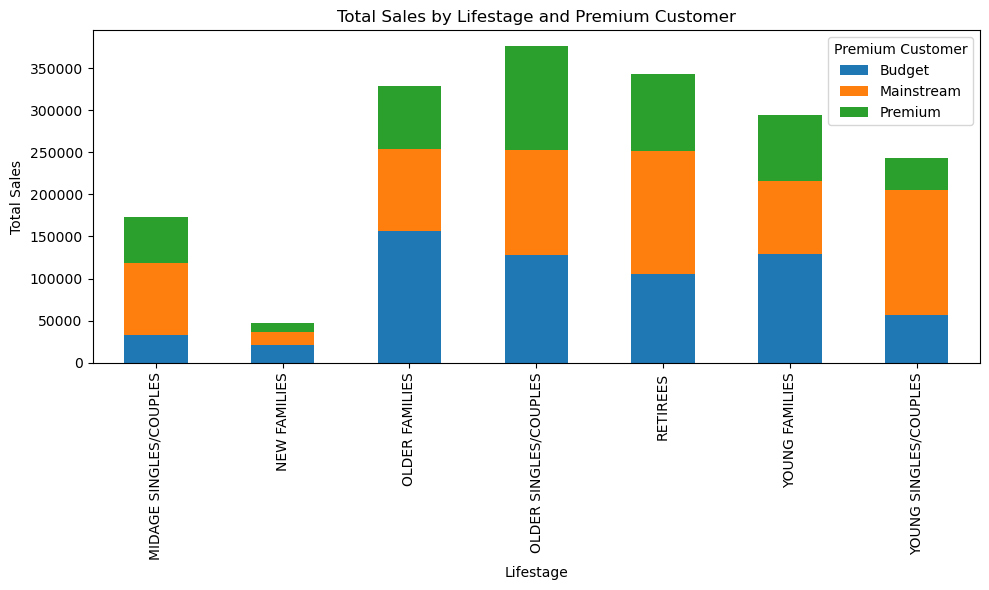

In [172]:
# plot total sales by lifestage and premium_customer, we can use a stackedbar plot to show the total sales for each combination of lifestage and premium_customer, and we can use different colors to differentiate between premium and non-premium customers. and show the number of proportions of each lifestage and premium_customer combination in the plot, so that we can see which group contributes more to the total sales and identify any patterns or trends in the data.
sales_by_lifestage_premium = QVI_complete.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['TOT_SALES'].sum().unstack()
sales_by_lifestage_premium.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Total Sales by Lifestage and Premium Customer')
plt.xlabel('Lifestage')
plt.ylabel('Total Sales')
plt.legend(title='Premium Customer', loc='upper right')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

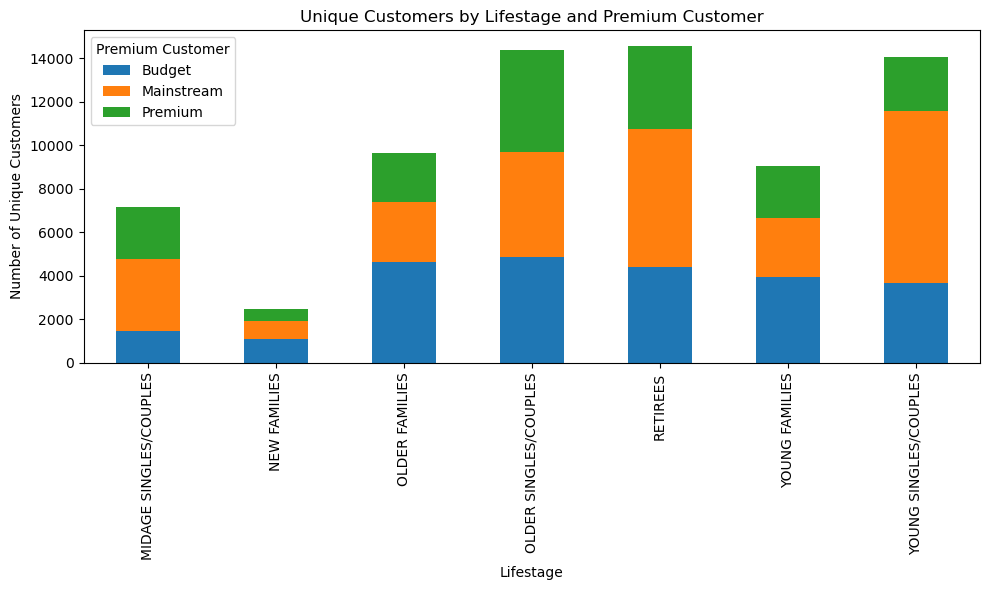

In [178]:
# plot the unique customers by lifestage and premium_customer, we can use the groupby function to group the data by lifestage and premium_customer, and then use the nunique function to count the number of unique customers in each group, so that we can see which group has more unique customers and identify any patterns or trends in the data.
unique_customers_by_group = QVI_complete.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['LYLTY_CARD_NBR'].nunique().unstack()
unique_customers_by_group.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Unique Customers by Lifestage and Premium Customer')
plt.xlabel('Lifestage')
plt.ylabel('Number of Unique Customers')
plt.legend(title='Premium Customer', loc='upper left')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

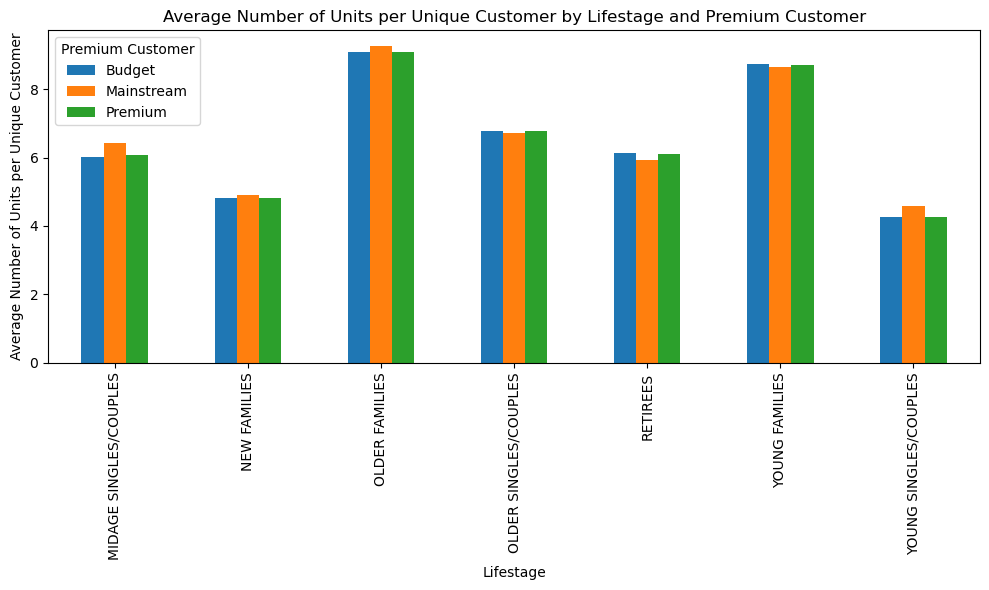

In [182]:
# average number of units per unique customer by lifestage and premium_customer
units_per_customer = QVI_complete.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['PROD_QTY'].sum() / QVI_complete.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['LYLTY_CARD_NBR'].nunique()
units_per_customer = units_per_customer.unstack()
units_per_customer.plot(kind='bar', stacked=False, figsize=(10, 6))
plt.title('Average Number of Units per Unique Customer by Lifestage and Premium Customer')
plt.xlabel('Lifestage')
plt.ylabel('Average Number of Units per Unique Customer')
plt.legend(title='Premium Customer', loc='upper left')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


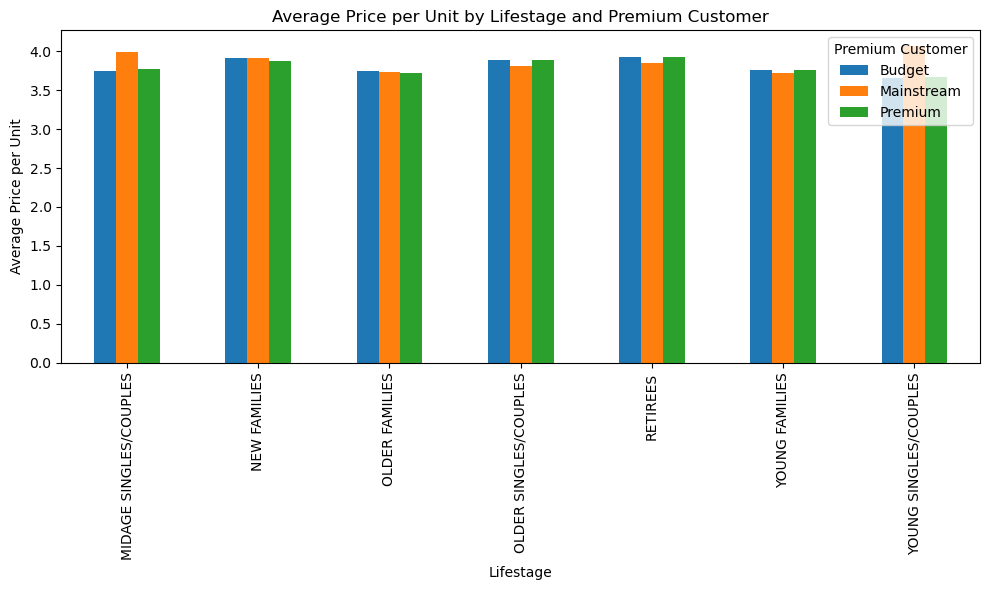

In [183]:
# average price per unit by lifestage and premium_customer
QVI_complete['PRICE_PER_UNIT'] = QVI_complete['TOT_SALES'] / QVI_complete['PROD_QTY']
price_per_unit = QVI_complete.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['PRICE_PER_UNIT'].mean().unstack()
price_per_unit.plot(kind='bar', stacked=False, figsize=(10, 6))
plt.title('Average Price per Unit by Lifestage and Premium Customer')
plt.xlabel('Lifestage')
plt.ylabel('Average Price per Unit')
plt.legend(title='Premium Customer', loc='upper right')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [188]:
QVI_complete.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,BRAND,LIFESTAGE,PREMIUM_CUSTOMER,PRICE_PER_UNIT
0,2018-10-17,1,1000,1,5,natural chip compny seasalt175g,2,6.0,natural,YOUNG SINGLES/COUPLES,Premium,3.00
1,2019-05-14,1,1307,348,66,ccs nacho cheese 175g,3,6.3,ccs,MIDAGE SINGLES/COUPLES,Budget,2.10
2,2019-05-20,1,1343,383,61,smiths crinkle cut chips chicken 170g,2,2.9,smiths,MIDAGE SINGLES/COUPLES,Budget,1.45
3,2018-08-17,2,2373,974,69,smiths chip thinly s/cream&onion 175g,5,15.0,smiths,MIDAGE SINGLES/COUPLES,Budget,3.00
4,2018-08-18,2,2426,1038,108,kettle tortilla chpshny&jlpno chili 150g,3,13.8,kettle,MIDAGE SINGLES/COUPLES,Budget,4.60


In [192]:
# do a t-test between PREMIUM_CUSTOMER, to see if there is a significant difference in the average price per unit, we can use the t-test to compare the means of the two groups and determine if the difference is statistically significant.
from scipy import stats

# 1. Create the price column by dividing TOT_SALES by PROD_QTY
QVI_complete['price'] = QVI_complete['TOT_SALES'] / QVI_complete['PROD_QTY']

# 2. Define the target lifestages
target_lifestages = ["YOUNG SINGLES/COUPLES", "MIDAGE SINGLES/COUPLES"]

# 3. Create the two groups
# Group 1: Mainstream in those lifestages
mainstream_group = QVI_complete[
    (QVI_complete['LIFESTAGE'].isin(target_lifestages)) & 
    (QVI_complete['PREMIUM_CUSTOMER'] == "Mainstream")
]['price']

# Group 2: NOT Mainstream (Budget + Premium) in those lifestages
others_group = QVI_complete[
    (QVI_complete['LIFESTAGE'].isin(target_lifestages)) & 
    (QVI_complete['PREMIUM_CUSTOMER'] != "Mainstream")
]['price']

# 4. Perform the Independent T-test
# equal_var=False makes it a Welch's T-test (matches R default)
# alternative='greater' matches the professor's one-sided test
t_stat, p_value = stats.ttest_ind(
    mainstream_group, 
    others_group, 
    equal_var=False, 
    alternative='greater'
)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.20f}")

print("Conclusion:  the unit price for mainstream, young and mid-age singles and couples are significantly higher than that of budget or premium, young and midage singles and couples.")

T-statistic: 37.6244
P-value: 0.00000000000000000000
Conclusion:  the unit price for mainstream, young and mid-age singles and couples are significantly higher than that of budget or premium, young and midage singles and couples.
